# Tutorial 8: QC Dashboard — SOLUTIONS

**FOR INSTRUCTOR USE ONLY**

In [1]:
options(repos = c(CRAN = "https://cloud.r-project.org"))
library(ggplot2)

In [2]:
# Data
qc_data <- data.frame(
  Day = 1:60,
  Creatinine = c(
    1.02, 0.98, 1.05, 0.96, 1.01, 1.03, 0.99, 1.04, 0.97, 1.00,
    1.02, 0.98, 1.06, 0.95, 1.01, 1.03, 0.99, 1.02, 0.97, 1.00,
    1.04, 0.98, 1.05, 0.96, 1.02, 1.00, 1.03, 0.99, 1.01, 0.97,
    1.12, 1.15, 1.08, 1.18, 1.10, 1.14, 1.09, 1.16, 1.12, 1.11,
    1.17, 1.08, 1.13, 1.19, 1.10, 1.15, 1.12, 1.14, 1.09, 1.16,
    1.22, 1.11, 1.18, 1.13, 1.15, 1.10, 1.17, 1.12, 1.14, 1.19
  )
)

In [3]:
# SOLUTION: Step 2 - Baseline (first 20 days)
baseline <- qc_data$Creatinine[1:20]
baseline_mean <- mean(baseline)
baseline_sd <- sd(baseline)

cat("Baseline Mean:", round(baseline_mean, 3), "\n")
cat("Baseline SD:", round(baseline_sd, 3))

Baseline Mean: 1.004 
Baseline SD: 0.03

In [4]:
# Control limits
upper_3sd <- baseline_mean + 3 * baseline_sd
lower_3sd <- baseline_mean - 3 * baseline_sd
upper_2sd <- baseline_mean + 2 * baseline_sd
lower_2sd <- baseline_mean - 2 * baseline_sd

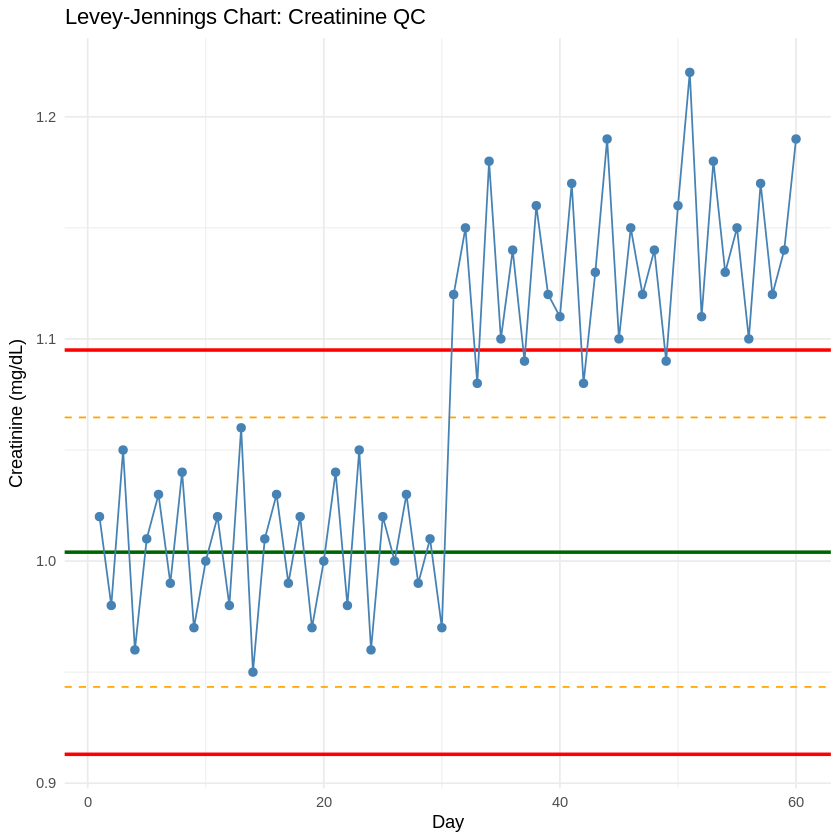

In [ ]:
# SOLUTION: Step 4 - upper_3sd
ggplot(qc_data, aes(x = Day, y = Creatinine)) +
  # Control lines
  geom_hline(yintercept = baseline_mean, color = "darkgreen", linewidth = 1) +
  geom_hline(yintercept = upper_2sd, color = "orange", linetype = "dashed") +
  geom_hline(yintercept = lower_2sd, color = "orange", linetype = "dashed") +
  geom_hline(yintercept = upper_3sd, color = "red", linewidth = 1) +  # <-- FILL IN (upper 3SD limit)
  geom_hline(yintercept = lower_3sd, color = "red", linewidth = 1) +
  
  # Data
  geom_line(color = "steelblue") +
  geom_point(size = 2, color = "steelblue") +
  
  labs(title = "Levey-Jennings Chart: Creatinine QC",
       x = "Day", y = "Creatinine (mg/dL)") +
  theme_minimal()

In [5]:
# SOLUTION: Step 5 - Flag violations (3 SD)
qc_data$Violation <- abs(qc_data$Creatinine - baseline_mean) > 3 * baseline_sd
cat("Violations:", sum(qc_data$Violation))

Violations: 26

## Sample Interpretation

"The systematic positive shift at Day 31 likely indicates a **reagent lot change** or **calibration drift**. The QC values jumped from a mean of ~1.00 to ~1.14 mg/dL, which is clinically significant for creatinine.

**Actions:**
1. Check reagent lot records for changes on/around Day 31
2. Review calibration logs
3. Recalibrate analyzer
4. Consider reviewing patient results from Days 31-60"